In [14]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
    classification_report, f1_score, roc_auc_score,)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [15]:
df = pd.read_excel("data/parkinsons.xlsx")

In [16]:
print("Shape:", df.shape)
df.info()

Shape: (195, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-n

In [17]:
print(df["status"].value_counts(normalize=True))

status
1    0.753846
0    0.246154
Name: proportion, dtype: float64


In [18]:
df.drop(["name"], axis=1, inplace=True)

In [19]:
X = df.drop(columns=["status"])
y = df["status"]

In [20]:
print(X.skew().sort_values(ascending=False))

NHR                 4.220709
Jitter:DDP          3.362058
MDVP:RAP            3.360708
MDVP:Jitter(%)      3.084946
MDVP:PPQ            3.073892
MDVP:Jitter(Abs)    2.649071
MDVP:APQ            2.618047
MDVP:Fhi(Hz)        2.542146
MDVP:Shimmer(dB)    1.999389
Shimmer:APQ5        1.798697
MDVP:Shimmer        1.666480
Shimmer:DDA         1.580618
Shimmer:APQ3        1.580576
MDVP:Flo(Hz)        1.217350
PPE                 0.797491
MDVP:Fo(Hz)         0.591737
spread1             0.432139
D2                  0.430384
spread2             0.144430
DFA                -0.033214
RPDE               -0.143402
HNR                -0.514317
dtype: float64


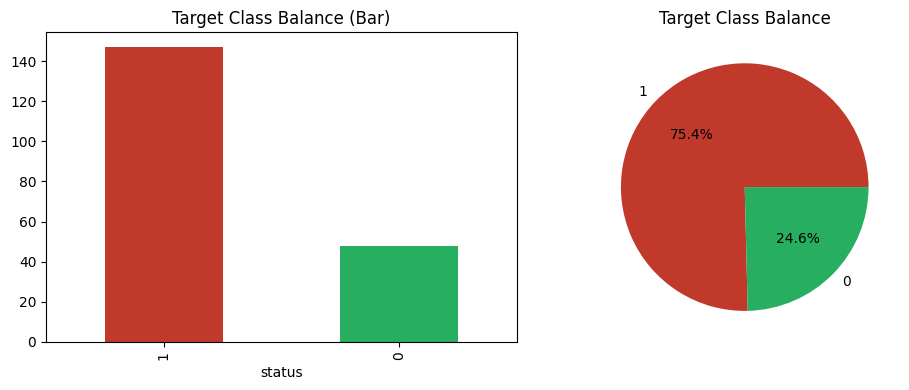

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y.value_counts().plot(
    kind="bar", color=["#c0392b", "#27ae60"], ax=axes[0]
)
axes[0].set_ylabel("")
axes[0].set_title("Target Class Balance (Bar)")

y.value_counts().plot(
    kind="pie", autopct="%1.1f%%", colors=["#c0392b", "#27ae60"], ax=axes[1]
)
axes[1].set_ylabel("")
axes[1].set_title("Target Class Balance")
plt.tight_layout()
plt.show()

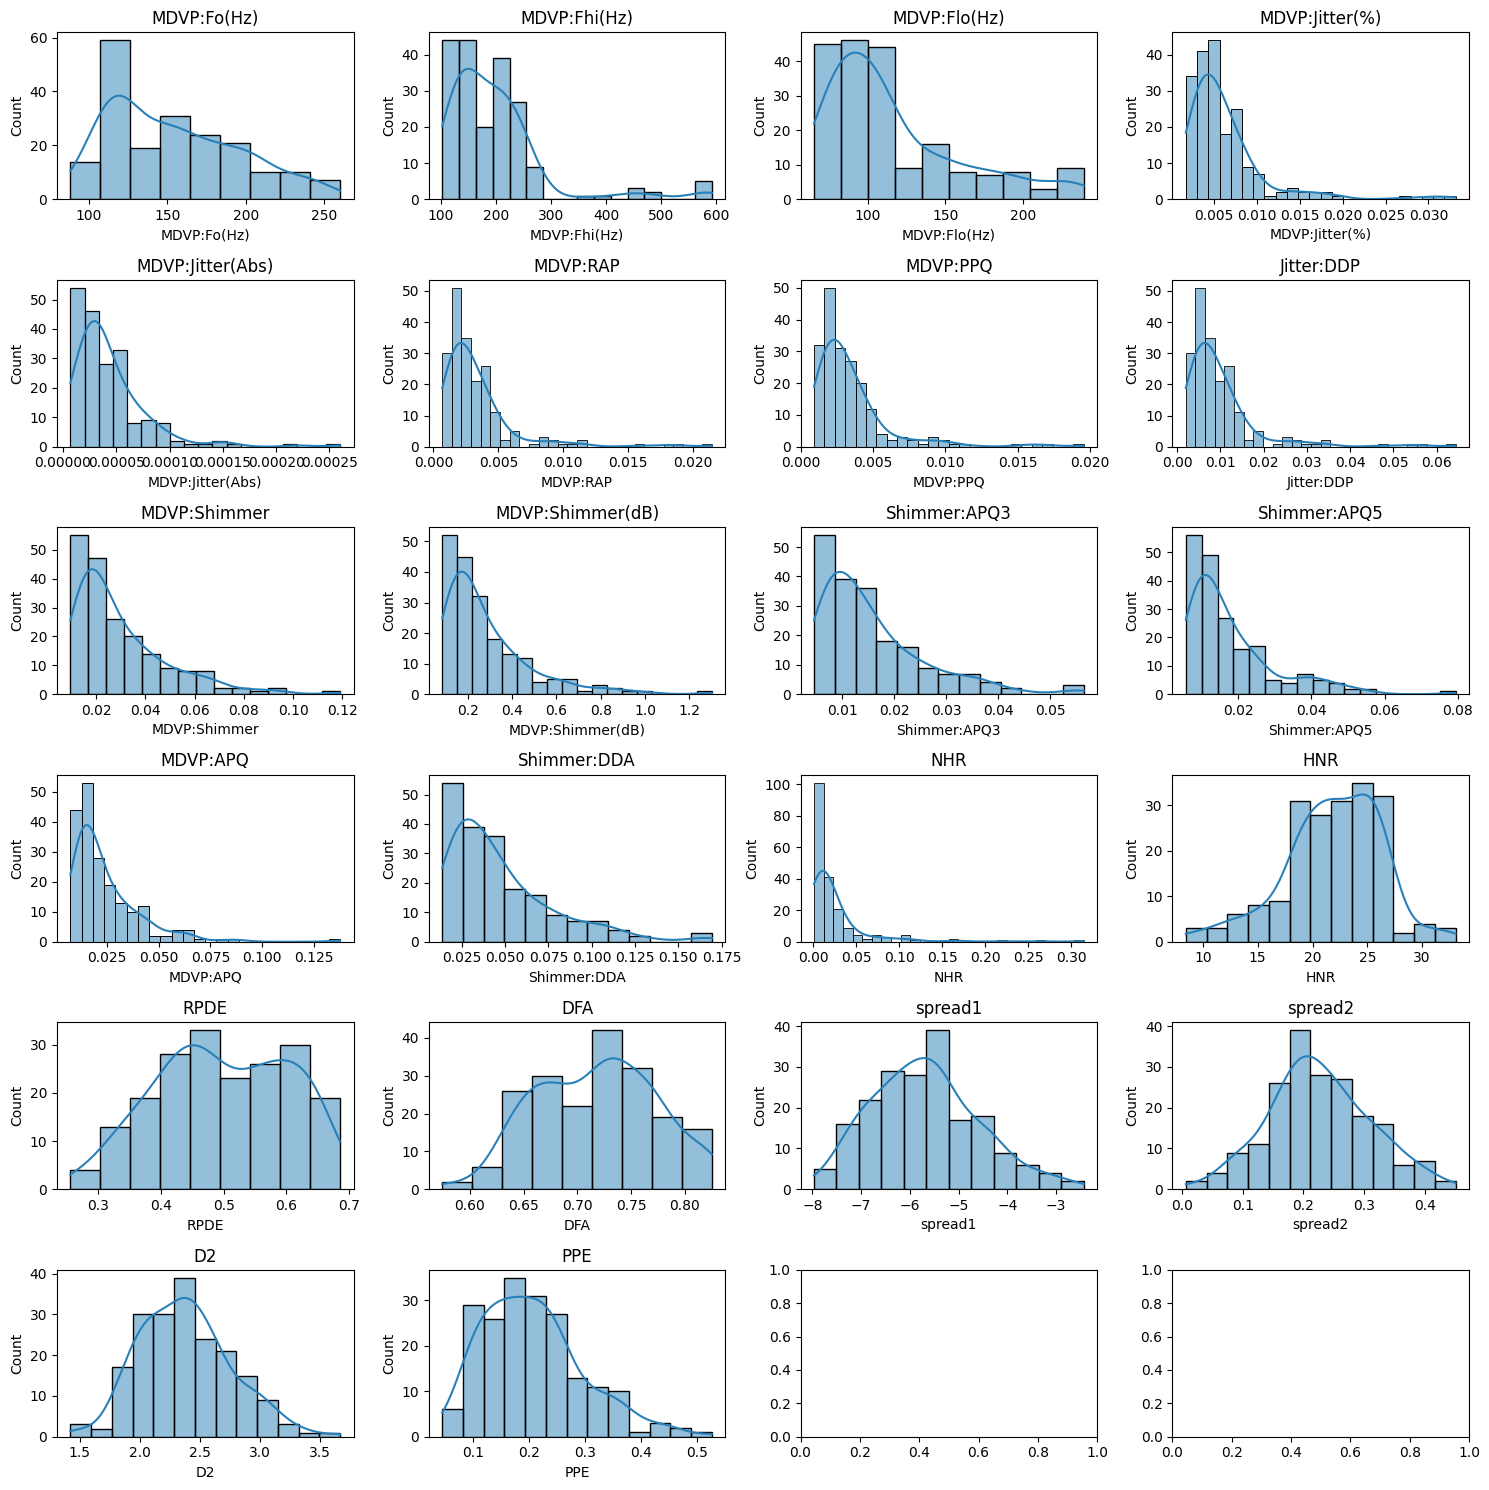

In [23]:
fig, axes = plt.subplots(6, 4, figsize=(15, 15))
for ax, col in zip(axes.flat, X):
    sns.histplot(df[col], kde=True, ax=ax, color="#2980b9")
    ax.set_title(col)
for ax in axes.flat[len(X):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

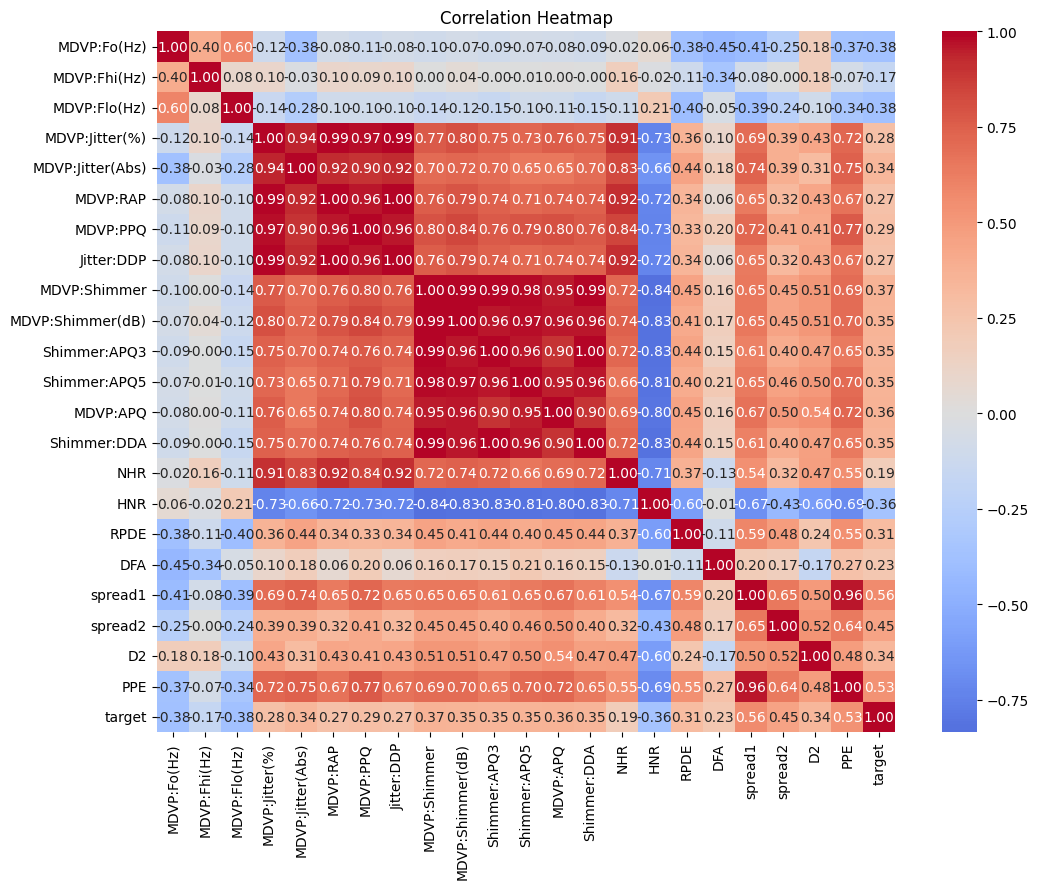

In [24]:
corr = X.assign(target=(y).astype(int)).corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Pipeline

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(156, 22) (39, 22)


In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Cross-validation evaluation

In [27]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # for XGBoost

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight, eval_metric="logloss",
        random_state=42, n_jobs=-1
    ),
}

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["roc_auc", "f1", "accuracy"]

cv_results = {}
print(f"{'Model':<20}{'ROC-AUC':>12}{'F1':>12}{'Accuracy':>12}")
print("-" * 56)
for name, clf in models.items():
    scores = cross_validate(clf, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<20}{scores['test_roc_auc'].mean():>12.4f}"
          f"{scores['test_roc_auc'].mean():>12.4f}{scores['test_accuracy'].mean():>12.4f}")

best_name = max(cv_results, key=lambda n: cv_results[n]["test_roc_auc"].mean())
print(f"\nBest model by mean CV ROC_AUC: {best_name}")

Model                    ROC-AUC          F1    Accuracy
--------------------------------------------------------
LogisticRegression        0.9004      0.9004      0.8141
RandomForest              0.9307      0.9307      0.8526
XGBoost                   0.9602      0.9602      0.8782

Best model by mean CV ROC_AUC: XGBoost


In [29]:
best_model = models[best_name]
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Parkinsons", "Parkinsons"]))

Accuracy : 0.9231
ROC-AUC  : 0.9828
F1       : 0.9492

               precision    recall  f1-score   support

No Parkinsons       0.89      0.80      0.84        10
   Parkinsons       0.93      0.97      0.95        29

     accuracy                           0.92        39
    macro avg       0.91      0.88      0.90        39
 weighted avg       0.92      0.92      0.92        39



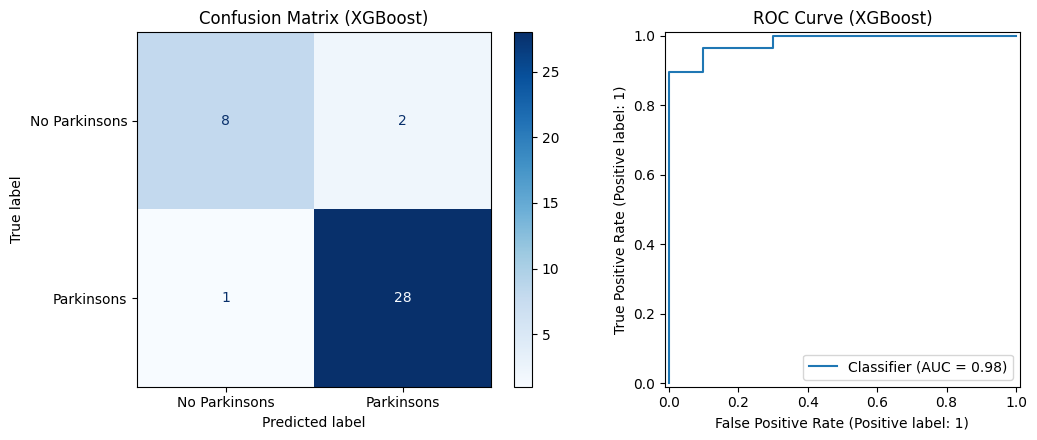

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No Parkinsons", "Parkinsons"], cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"Confusion Matrix ({best_name})")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"ROC Curve ({best_name})")
plt.tight_layout()
plt.show()

Saving Pipeline

In [31]:
parkinsons_model = {
    "model": best_model,
    "model_name": best_name,
    "scaler": scaler,
    "feature_columns": list(X.columns),
}
joblib.dump(parkinsons_model, "parkinsons_model.joblib")

['parkinsons_model.joblib']